In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("devdgohil/the-oxfordiiit-pet-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset


In [2]:
import os
import json

In [3]:
import sys
import importlib

sys.path.insert(0, "/kaggle/input/models/mrheavenly/sasdasd/transformers/default/1")

import train_extractor_scratch as ex
importlib.reload(ex)

<module 'train_extractor_scratch' from '/kaggle/input/models/mrheavenly/sasdasd/transformers/default/1/train_extractor_scratch.py'>

In [4]:
img_dir = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images"
mask_dir = "/kaggle/input/datasets/mrheavenly/masks-oxford"
config_path = "/kaggle/working/config_extractor_scratch.json"
ae_weights_path = "/kaggle/input/models/mrheavenly/stage-2b/pytorch/default/1/best_weights_wm.pth"
injector_path = "/kaggle/input/models/mrheavenly/stage-2b/pytorch/default/1/injector.pth"

In [5]:
# Create directories in the writable /working path
!mkdir -p /kaggle/working/clean_pet_data/images
!mkdir -p /kaggle/working/clean_pet_data/masks

# Note: Ensure these paths match your actual input structure
!cp -r /kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images/* /kaggle/working/clean_pet_data/images/
!cp -r /kaggle/input/datasets/mrheavenly/masks-oxford/* /kaggle/working/clean_pet_data/masks/

In [6]:
import os
import shutil
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# --- PATHS ---
# Source (Read-Only)
SRC_IMG_DIR = img_dir
SRC_MASK_DIR = mask_dir

# Destination (Writable)
IMG_DIR = '/kaggle/working/clean_pet_data/images'
MASK_DIR = '/kaggle/working/clean_pet_data/masks'

def is_corrupted_binary(filepath):
    """Step 2: Check raw binary for truncation (Missing FF D9)."""
    try:
        if os.path.getsize(filepath) == 0:
            return True
        if filepath.lower().endswith(('.jpg', '.jpeg')):
            with open(filepath, 'rb') as f:
                f.seek(-2, 2)
                if f.read() != b'\xff\xd9':
                    return True
        return False
    except Exception:
        return True

def sanitize_and_clean():
    """Step 3: Binary cleanup and Metadata stripping via re-encoding."""
    SUPPORTED = {'.jpg', '.jpeg', '.png', '.webp', '.gif'}
    img_files = [f for f in os.listdir(IMG_DIR) if os.path.splitext(f)[1].lower() in SUPPORTED]
    
    corrupted_count = 0
    sanitized_count = 0
    
    print(f"Processing {len(img_files)} images...")

    for img_name in img_files:
        img_path = os.path.join(IMG_DIR, img_name)
        base_name = os.path.splitext(img_name)[0]
        
        # Match mask
        mask_path = None
        for suffix in ['.png', '_mask.png']:
            temp_path = os.path.join(MASK_DIR, base_name + suffix)
            if os.path.exists(temp_path):
                mask_path = temp_path
                break

        # Check for binary corruption (truncation)
        if is_corrupted_binary(img_path) or (mask_path and is_corrupted_binary(mask_path)):
            print(f"  [DELETING] {base_name} (Truncated)")
            if os.path.exists(img_path): os.remove(img_path)
            if mask_path and os.path.exists(mask_path): os.remove(mask_path)
            corrupted_count += 1
            continue

        # Re-encode to strip "extraneous bytes" warnings
        if img_path.lower().endswith(('.jpg', '.jpeg')):
            try:
                with Image.open(img_path) as img:
                    img = img.convert('RGB')
                    img.save(img_path, 'JPEG', quality=100, subsampling=0)
                sanitized_count += 1
            except Exception as e:
                print(f"  [DELETING] {base_name} (Re-encode failed: {e})")
                if os.path.exists(img_path): os.remove(img_path)
                if mask_path: os.remove(mask_path)
                corrupted_count += 1

    print("-" * 40)
    print(f"Cleanup Finished.")
    print(f"Total Deleted (Corrupt): {corrupted_count}")
    print(f"Total Re-encoded (Sanitized): {sanitized_count}")

if __name__ == '__main__':
    sanitize_and_clean()

Processing 7390 images...
  [DELETING] Egyptian_Mau_138 (Truncated)
  [DELETING] Abyssinian_5 (Truncated)
  [DELETING] Egyptian_Mau_14 (Truncated)
  [DELETING] Egyptian_Mau_191 (Truncated)
  [DELETING] Abyssinian_34 (Truncated)
  [DELETING] Egyptian_Mau_139 (Truncated)
  [DELETING] Egyptian_Mau_177 (Truncated)
  [DELETING] Egyptian_Mau_167 (Truncated)
  [DELETING] Egyptian_Mau_145 (Truncated)
  [DELETING] Egyptian_Mau_156 (Truncated)
  [DELETING] Egyptian_Mau_186 (Truncated)
----------------------------------------
Cleanup Finished.
Total Deleted (Corrupt): 11
Total Re-encoded (Sanitized): 7379


In [7]:
print(len(os.listdir(IMG_DIR)))
print(len(os.listdir(MASK_DIR)))

7382
7379


In [8]:
config_extractor_pretrained = {}
with open(config_path, "w") as f:
    json.dump(config_extractor_pretrained, f)

In [ ]:
master_json = {
  "paths": {
    "images_dir": "/kaggle/input/oxford-iiit-pet/images",
    "mask_dir": "/kaggle/input/oxford-iiit-pet/annotations/trimaps"
  },
  "shared": {
    "img_size": 224,
    "max_samples": null,
    "split_size": 0.85,
    "num_workers": 4,
    "grad_clip": 1.0,
    "save_every": 5,
    "latent_channels": 256
  },
  "stage1_unet": {
    "checkpoint_dir": "/kaggle/working/checkpoints_unet",
    "best_model_dir": "/kaggle/working/best_model_unet",
    "batch_size": 16,
    "max_iterations": 50,
    "lr": 0.001,
    "weight_decay": 0.0001,
    "accum_steps": 2,
    "patience": 10,
    "min_delta": 0.0001,
    "bce_weight": 0.4,
    "dice_weight": 0.4,
    "kl_weight": 0.2,
    "cache_ram": true,
    "resume": null
  },
  "stage2_autoencoder": {
    "checkpoint_dir": "/kaggle/working/checkpoints_ae",
    "best_model_dir": "/kaggle/working/best_model_ae",
    "batch_size": 16,
    "max_iterations": 60,
    "lr": 0.0002,
    "weight_decay": 0.00001,
    "accum_steps": 1,
    "patience": 8,
    "min_delta": 0.000001,
    "lambda_l1": 1.0,
    "lambda_perceptual": 0.1,
    "cache_ram": false,
    "max_cache_size": 0,
    "resume": null
  },
  "stage3_extractor": {
    "images_dir": "/kaggle/working/clean_pet_data/images",
    "mask_dir": "/kaggle/working/clean_pet_data/masks",
    "checkpoint_dir": "/kaggle/working/checkpoints_e2e",
    "best_model_dir": "/kaggle/working/best_model_e2e",
    "ae_weights": "/kaggle/input/models/mrheavenly/stage-2b/pytorch/default/1/best_weights_wm.pth",
    "injector_weights": "/kaggle/input/models/mrheavenly/stage-2b/pytorch/default/1/injector.pth",
    "alpha": 0.15,
    "w1_seed": "object",
    "w2_seed": "background",
    "attack_p": 0.8,
    "attack_warmup_epochs": 5,
    "batch_size": 4,
    "max_iterations": 80,
    "lr": 0.0001,
    "weight_decay": 0.0001,
    "accum_steps": 4,
    "patience": 15,
    "min_delta": 0.0001,
    "lambda_l1": 5.0,
    "lambda_ext": 5.0,
    "cache_ram": false,
    "resume": null
  },
  "stage4_gan": {
    "images_dir": "/kaggle/working/clean_pet_data/images",
    "mask_dir": "/kaggle/working/clean_pet_data/masks",
    "checkpoint_dir": "/kaggle/working/checkpoints_gan",
    "best_model_dir": "/kaggle/working/best_model_gan",
    "ae_weights": "/kaggle/input/models/mrheavenly/ae-model/pytorch/default/1/best_weights_ae.pth",
    "injector_weights": "/kaggle/input/models/mrheavenly/ext-weights/pytorch/default/1/best_weights.pth",
    "ext_weights": "/kaggle/input/models/mrheavenly/ext-weights/pytorch/default/1/best_weights.pth",
    "w1_seed": "object",
    "w2_seed": "background",
    "attack_p": 0.8,
    "attack_warmup_epochs": 2,
    "batch_size": 4,
    "max_iterations": 60,
    "lr_g": 0.0001,
    "lr_d": 0.00005,
    "weight_decay": 0.0001,
    "accum_steps": 4,
    "patience": 15,
    "min_delta": 0.0001,
    "lambda_l1": 10.0,
    "lambda_ext": 5.0,
    "lambda_gan": 1.0,
    "resume": null
  },
  
  "inference": {
    "seg_weights": "/kaggle/working/best_model_unet/best_weights.pth",
    "ae_weights": "/kaggle/working/best_model_ae/best_weights.pth",
    "ext_weights": "/kaggle/working/best_model_e2e/best_weights.pth",
    "gan_ae_weights": "/kaggle/working/best_model_gan/best_gan_weights.pth",
    "device": "cuda:0",
    "watermark_strength_obj": 0.5,
    "watermark_strength_bg": 3.5,
    "extraction_threshold": 0.5,
    "input_image": "/kaggle/input/oxford-iiit-pet/images/Abyssinian_1.jpg"
  }
}

In [11]:
import json

# 1. Your dictionary
master_json = {
  "paths": {
    "images_dir": "/kaggle/input/oxford-iiit-pet/images",
    "mask_dir": "/kaggle/input/oxford-iiit-pet/annotations/trimaps"
  },
  "shared": {
    "img_size": 224,
    "max_samples": None,
    "split_size": 0.85,
    "num_workers": 4,
    "grad_clip": 1.0,
    "save_every": 5,
    "latent_channels": 256
  },
  "stage1_unet": {
    "checkpoint_dir": "/kaggle/working/checkpoints_unet",
    "best_model_dir": "/kaggle/working/best_model_unet",
    "batch_size": 16,
    "max_iterations": 50,
    "lr": 0.001,
    "weight_decay": 0.0001,
    "accum_steps": 2,
    "patience": 10,
    "min_delta": 0.0001,
    "bce_weight": 0.4,
    "dice_weight": 0.4,
    "kl_weight": 0.2,
    "cache_ram": True,
    "resume": None
  },
  "stage2_autoencoder": {
    "checkpoint_dir": "/kaggle/working/checkpoints_ae",
    "best_model_dir": "/kaggle/working/best_model_ae",
    "batch_size": 16,
    "max_iterations": 60,
    "lr": 0.0002,
    "weight_decay": 0.00001,
    "accum_steps": 1,
    "patience": 8,
    "min_delta": 0.000001,
    "lambda_l1": 1.0,
    "lambda_perceptual": 0.1,
    "cache_ram": False,
    "max_cache_size": 0,
    "resume": None
  },
  "stage3_extractor": {
    "images_dir": "/kaggle/working/clean_pet_data/images",
    "mask_dir": "/kaggle/working/clean_pet_data/masks",
    "checkpoint_dir": "/kaggle/working/checkpoints_e2e",
    "best_model_dir": "/kaggle/working/best_model_e2e",
    "ae_weights": "/kaggle/input/models/mrheavenly/stage-2b/pytorch/default/1/best_weights_wm.pth",
    "injector_weights": "/kaggle/input/models/mrheavenly/stage-2b/pytorch/default/1/injector.pth",
    "alpha": 0.15,
    "w1_seed": "object",
    "w2_seed": "background",
    "attack_p": 0.8,
    "attack_warmup_epochs": 5,
    "batch_size": 4,
    "max_iterations": 80,
    "lr": 0.0001,
    "weight_decay": 0.0001,
    "accum_steps": 4,
    "patience": 15,
    "min_delta": 0.0001,
    "lambda_l1": 5.0,
    "lambda_ext": 5.0,
    "cache_ram": False,
    "resume": None
  },
  "stage4_gan": {
    "images_dir": "/kaggle/working/clean_pet_data/images",
    "mask_dir": "/kaggle/working/clean_pet_data/masks",
    "checkpoint_dir": "/kaggle/working/checkpoints_gan",
    "best_model_dir": "/kaggle/working/best_model_gan",
    "ae_weights": "/kaggle/input/models/mrheavenly/ae-model/pytorch/default/1/best_weights_ae.pth",
    "injector_weights": "/kaggle/input/models/mrheavenly/ext-weights/pytorch/default/1/best_weights.pth",
    "ext_weights": "/kaggle/input/models/mrheavenly/ext-weights/pytorch/default/1/best_weights.pth",
    "w1_seed": "object",
    "w2_seed": "background",
    "attack_p": 0.8,
    "attack_warmup_epochs": 2,
    "batch_size": 4,
    "max_iterations": 60,
    "lr_g": 0.0001,
    "lr_d": 0.00005,
    "weight_decay": 0.0001,
    "accum_steps": 4,
    "patience": 15,
    "min_delta": 0.0001,
    "lambda_l1": 10.0,
    "lambda_ext": 5.0,
    "lambda_gan": 1.0,
    "resume": None
  },
  "inference": {
    "seg_weights": "/kaggle/working/best_model_unet/best_weights.pth",
    "ae_weights": "/kaggle/working/best_model_ae/best_weights.pth",
    "ext_weights": "/kaggle/working/best_model_e2e/best_weights.pth",
    "gan_ae_weights": "/kaggle/working/best_model_gan/best_gan_weights.pth",
    "device": "cuda:0",
    "watermark_strength_obj": 0.5,
    "watermark_strength_bg": 3.5,
    "extraction_threshold": 0.5,
    "input_image": "/kaggle/input/oxford-iiit-pet/images/Abyssinian_1.jpg"
  }
}

# 2. Define the path where it will be saved
config_path = '/kaggle/working/master_config.json'

# 3. Save the dictionary as a JSON file
with open(config_path, 'w') as f:
    json.dump(master_json, f, indent=2)

print(f"Config successfully saved to {config_path}")

Config successfully saved to /kaggle/working/master_config.json


In [12]:
!rm -rf /kaggle/working/checkpoints_ext_pt
!rm -rf /kaggle/working/best_model_ext_pt

In [13]:
!python /kaggle/input/models/mrheavenly/sasdasd/transformers/default/1/train_extractor_scratch.py --config /kaggle/working/master_config.json

Rank 1 initializing on GPU Tesla T4
Rank 0 initializing on GPU Tesla T4
  [AE] loaded → /kaggle/input/models/mrheavenly/stage-2b/pytorch/default/1/best_weights_wm.pth
  [injector] loaded → /kaggle/input/models/mrheavenly/stage-2b/pytorch/default/1/injector.pth
  [extractor] ScratchCNN | params: 7.75M  (all trainable)
  [train] 6272 samples | [val] 1107 samples
  Starting scratch extractor training for 80 epochs

Epoch   1/80 | LR: 0.000100 | Time: 276.9s
  Train | total=26.92768  rec=0.18164  corr_o=+0.2491  corr_b=+0.2445
  Val   | total=13.90344  rec=0.05112  corr_o=+0.4846  corr_b=+0.5191
----------------------------------------------------------------------
    [ckpt] saved → /kaggle/working/checkpoints_e2e/best_model.pth
    [best] val=13.90344  corr_o=0.4846  corr_b=0.5191
    [best] → /kaggle/working/best_model_e2e/best_weights.pth
Epoch   2/80 | LR: 0.000100 | Time: 253.9s
  Train | total=14.35920  rec=0.06003  corr_o=+0.5083  corr_b=+0.4948
  Val   | total=11.37370  rec=0.0465

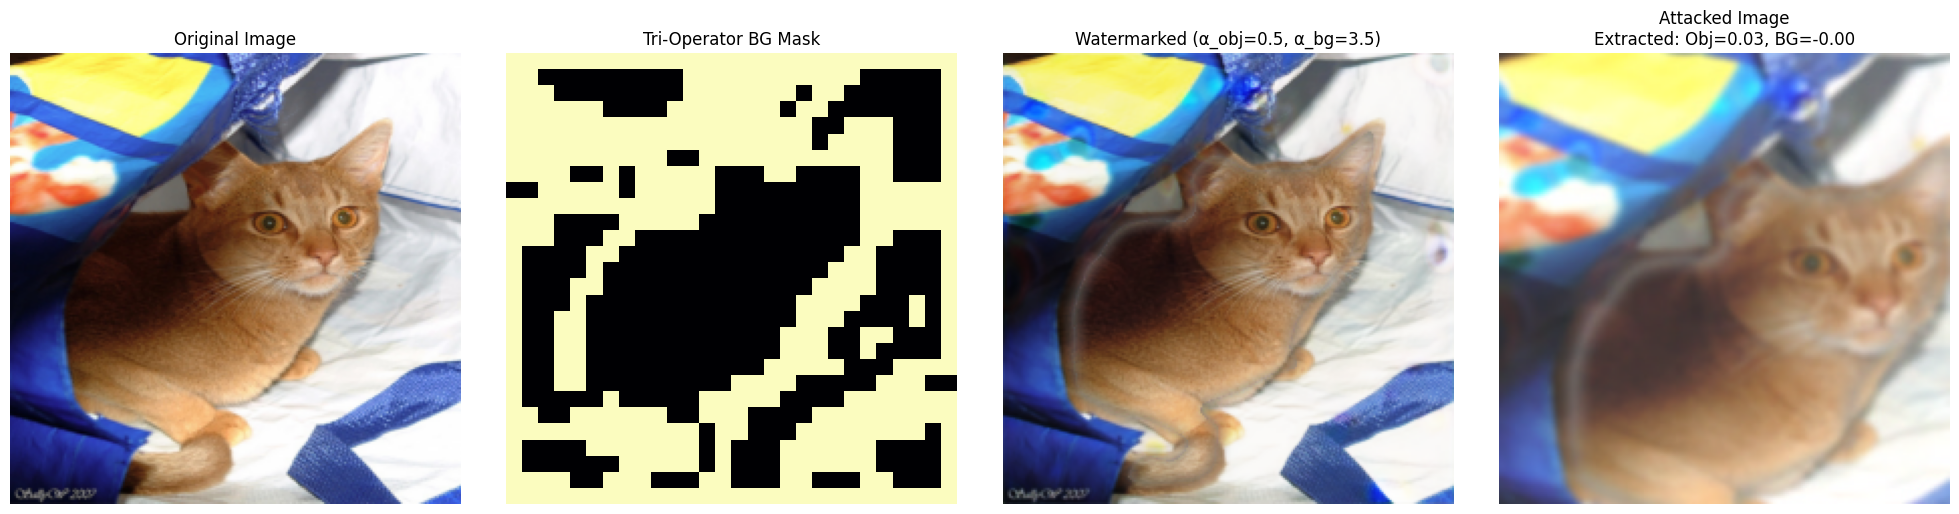

In [22]:
import torch
import json
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from collections import OrderedDict
from torchvision.io import read_image
import torch.nn.functional as F

# Assuming 'ex' is your imported module
import train_extractor_scratch as ex 

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Load the Config safely
config_path = '/kaggle/working/master_config.json'
with open(config_path, 'r') as f:
    master_json = json.load(f)
config = master_json['stage3_extractor'] 

def clean_ddp_state_dict(state_dict):
    clean_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '') if k.startswith('module.') else k
        clean_state_dict[name] = v
    return clean_state_dict

# 2. Load the Autoencoder
ae = ex.DualAutoencoder().to(device)
ae_raw_state = torch.load(config['ae_weights'], map_location=device)
ae.load_state_dict(clean_ddp_state_dict(ae_raw_state.get('model', ae_raw_state)), strict=True)
ae.eval()

# 3. Load the Injector (NO WEIGHTS NEEDED NOW! Mathematically generated)
injector = ex.SSWatermarkInjector(256, 28, 28, w1_seed="object", w2_seed="background").to(device)
injector.eval()

# 4. Load the Extractor (CORRECTED CLASS NAME)
extractor = ex.HeavyWatermarkDecoder(num_res_blocks=6).to(device)
ext_raw_state = torch.load('/kaggle/working/best_model_e2e/best_weights.pth', map_location=device)
if 'model' in ext_raw_state: ext_raw_state = ext_raw_state['model']
extractor.load_state_dict(clean_ddp_state_dict(ext_raw_state), strict=True)
extractor.eval()

# 5. Load the Edge Masker & Attack Layer
edge_masker = ex.TriOperatorEdgeMasker().to(device)
edge_masker.eval()
jpeg_attack = ex.AttackSimulationLayer(p_apply=1.0).to(device) 

# 6. Load Image
img_path = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images/Abyssinian_100.jpg"
mask_path = "/kaggle/input/datasets/mrheavenly/masks-oxford/Abyssinian_100_mask.png"

img_raw = read_image(img_path)
mask_raw = read_image(mask_path)

if img_raw.shape[0] == 4: img_raw = img_raw[:3]
elif img_raw.shape[0] == 1: img_raw = img_raw.repeat(3, 1, 1)

# Force the mask to be 1 channel (Grayscale)
if mask_raw.shape[0] > 1: mask_raw = mask_raw[0:1, :, :]
img_raw = img_raw.float().div(255.0)
mask_raw = (mask_raw > 127).float()

transform = ex.SegmentTransform(224, p=0.0) 
img, mask = transform(img_raw, mask_raw)

img = img.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)

objs = img * mask
bgs  = img * (1.0 - mask)

with torch.inference_mode():
    # A. Generate the Edge Masks
    edge_mask_obj = edge_masker(objs)
    edge_mask_bg = edge_masker(bgs)
    soft_masks = TF.gaussian_blur(mask, kernel_size=[15, 15], sigma=[5.0, 5.0])

    # B. Generate Watermarked Image using Differential Alphas
    wm_obj, wm_bg = ae.forward_watermarked(
        objs, bgs, injector, 
        alpha_obj=0.5, alpha_bg=3.5, 
        edge_mask_obj=edge_mask_obj, edge_mask_bg=edge_mask_bg
    )
    
    # C. Blend with Soft Masks
    wm_image = (wm_obj * soft_masks) + (wm_bg * (1.0 - soft_masks))
    
    # D. Apply JPEG Attack 
    attacked_image = jpeg_attack(wm_image, current_epoch=10, warmup_epochs=0)
    
    # E. Extract
    try:
        pred_wm, features = extractor(attacked_image, soft_masks)
    except TypeError:
        pred_wm, features = extractor(attacked_image) 
    
    # F. Calculate Correlation 
    true_w1 = injector.w1.mean(dim=1, keepdim=True).expand(1, -1, -1, -1)
    true_w2 = injector.w2.mean(dim=1, keepdim=True).expand(1, -1, -1, -1)
    target_wm = torch.cat([true_w1, true_w2], dim=1)
    
    corr_obj = F.cosine_similarity(pred_wm[:, 0:1].flatten(1), target_wm[:, 0:1].flatten(1), dim=1)
    corr_bg  = F.cosine_similarity(pred_wm[:, 1:2].flatten(1), target_wm[:, 1:2].flatten(1), dim=1)


# 7. Plot the Final Result
def to_numpy(t):
    return ((t[0].cpu().permute(1, 2, 0) * 0.5 + 0.5) * 255).clamp(0, 255).byte().numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(to_numpy(img))
axes[0].set_title("Original Image")

axes[1].imshow(edge_mask_bg[0, 0].cpu().numpy(), cmap='magma')
axes[1].set_title("Tri-Operator BG Mask")

axes[2].imshow(to_numpy(wm_image))
axes[2].set_title("Watermarked (α_obj=0.5, α_bg=3.5)")

axes[3].imshow(to_numpy(attacked_image))
axes[3].set_title(f"Attacked Image\nExtracted: Obj={corr_obj.item():.2f}, BG={corr_bg.item():.2f}")

for ax in axes: 
    ax.axis('off')
    
plt.tight_layout()
plt.savefig("inference_attacker.png")
plt.show()

In [18]:
import torch.nn.functional as F

# --- INSERT THIS RIGHT AFTER: bgs = img * (1.0 - mask) ---

print("\n--- RUNNING LATENT SPACE SANITY CHECK ---")
with torch.inference_mode(): 
    # 1. Encode the clean image to get the raw latent space
    z_clean, _ = ae.ae_obj.encode(objs)
    
    # 2. Generate the Edge Masks
    edge_mask_obj = edge_masker(objs)
    edge_mask_bg = edge_masker(bgs)
    
    # 3. Inject the watermark into the raw latent space
    z_wm_injected, _ = injector(
        z_clean, z_clean, # Passing z_clean twice just to test the object math
        alpha_obj=0.5, 
        alpha_bg=3.5, 
        edge_mask_obj=edge_mask_obj, 
        edge_mask_bg=edge_mask_bg
    )
    
    # 4. Isolate the added signal
    diff_latent_raw = z_wm_injected - z_clean
    
    print(f"Latent Diff Mean (abs): {diff_latent_raw.abs().mean().item():.6f}")
    print(f"Latent Diff Max  (abs): {diff_latent_raw.abs().max().item():.6f}")
    
    # 5. Direct Correlation Checks
    w1 = injector.w1  # The Object Watermark 
    B = z_wm_injected.shape[0]
    w1_flat = w1.flatten(1).expand(B, -1)
    
    # Check A
    corr_isolated = F.cosine_similarity(diff_latent_raw.flatten(1), w1_flat, dim=1)
    print(f"Check A - Correlation of isolated signal to w1: {corr_isolated.mean().item():.4f} (Target: ~1.000)")
    
    # Check B
    corr = F.cosine_similarity(z_wm_injected.flatten(1), w1_flat, dim=1)
    print(f"Check B - Correlation of full watermarked latent: {corr.mean().item():.4f}")
    
    # Check C
    corr_clean = F.cosine_similarity(z_clean.flatten(1), w1_flat, dim=1)
    print(f"Check C - Correlation of clean latent to w1:      {corr_clean.mean().item():.4f} (Target: ~0.000)")
print("-----------------------------------------\n")


--- RUNNING LATENT SPACE SANITY CHECK ---
Latent Diff Mean (abs): 0.106792
Latent Diff Max  (abs): 0.500000
Check A - Correlation of isolated signal to w1: 0.5116 (Target: ~1.000)
Check B - Correlation of full watermarked latent: 0.2686
Check C - Correlation of clean latent to w1:      0.0770 (Target: ~0.000)
-----------------------------------------



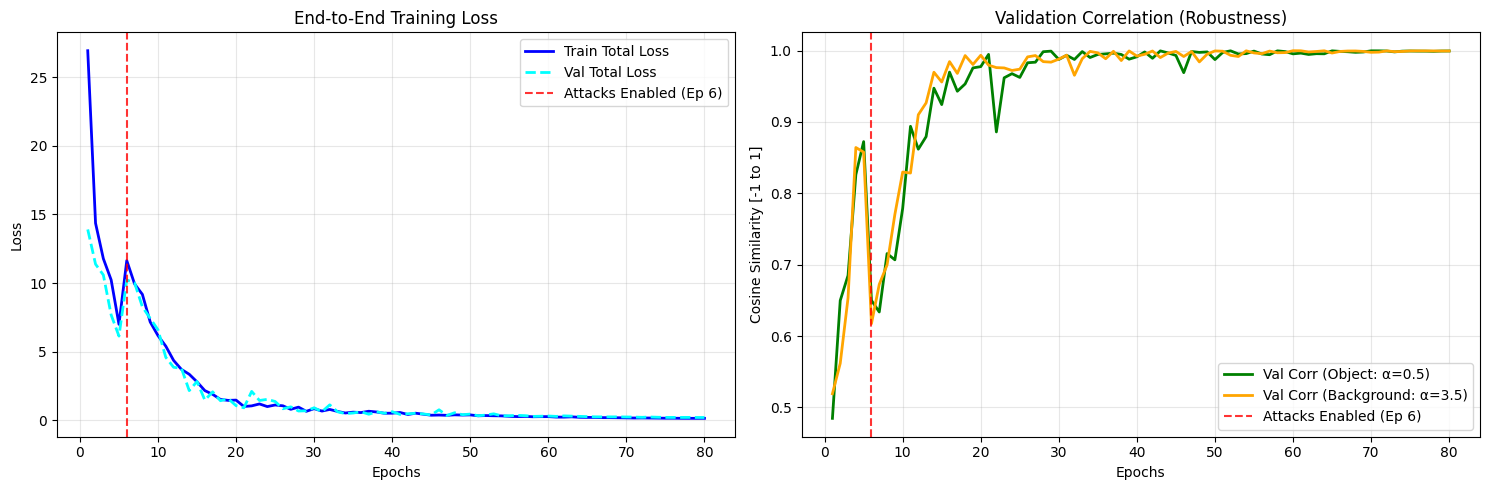

In [19]:
import json
import matplotlib.pyplot as plt

# 1. Path to your saved history JSON
history_path = "/kaggle/working/checkpoints_e2e/history.json" # Adjust if your path is different

# 2. Load the JSON data
with open(history_path, 'r') as f:
    history = json.load(f)

# 3. Extract the metrics
train_loss = history['train_total']
val_loss   = history['val_total']

val_corr_obj = history['breakdown']['corr_obj']['val']
val_corr_bg  = history['breakdown']['corr_bg']['val']

# 4. Define epochs and the attack threshold
epochs = list(range(1, len(train_loss) + 1))
attack_epoch = 6 # Because warmup_epochs was set to 5 (Epochs 1-5 are clean)

# 5. Create the Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: End-to-End Loss
ax1.plot(epochs, train_loss, label='Train Total Loss', color='blue', linewidth=2)
ax1.plot(epochs, val_loss, label='Val Total Loss', color='cyan', linestyle='--', linewidth=2)
ax1.axvline(x=attack_epoch, color='red', linestyle='--', alpha=0.8, label='Attacks Enabled (Ep 6)')
ax1.set_title('End-to-End Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Validation Correlation (Robustness)
ax2.plot(epochs, val_corr_obj, label='Val Corr (Object: α=0.5)', color='green', linewidth=2)
ax2.plot(epochs, val_corr_bg, label='Val Corr (Background: α=3.5)', color='orange', linewidth=2)
ax2.axvline(x=attack_epoch, color='red', linestyle='--', alpha=0.8, label='Attacks Enabled (Ep 6)')
ax2.set_title('Validation Correlation (Robustness)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Cosine Similarity [-1 to 1]')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("full_training_history_graph.png")
plt.show()

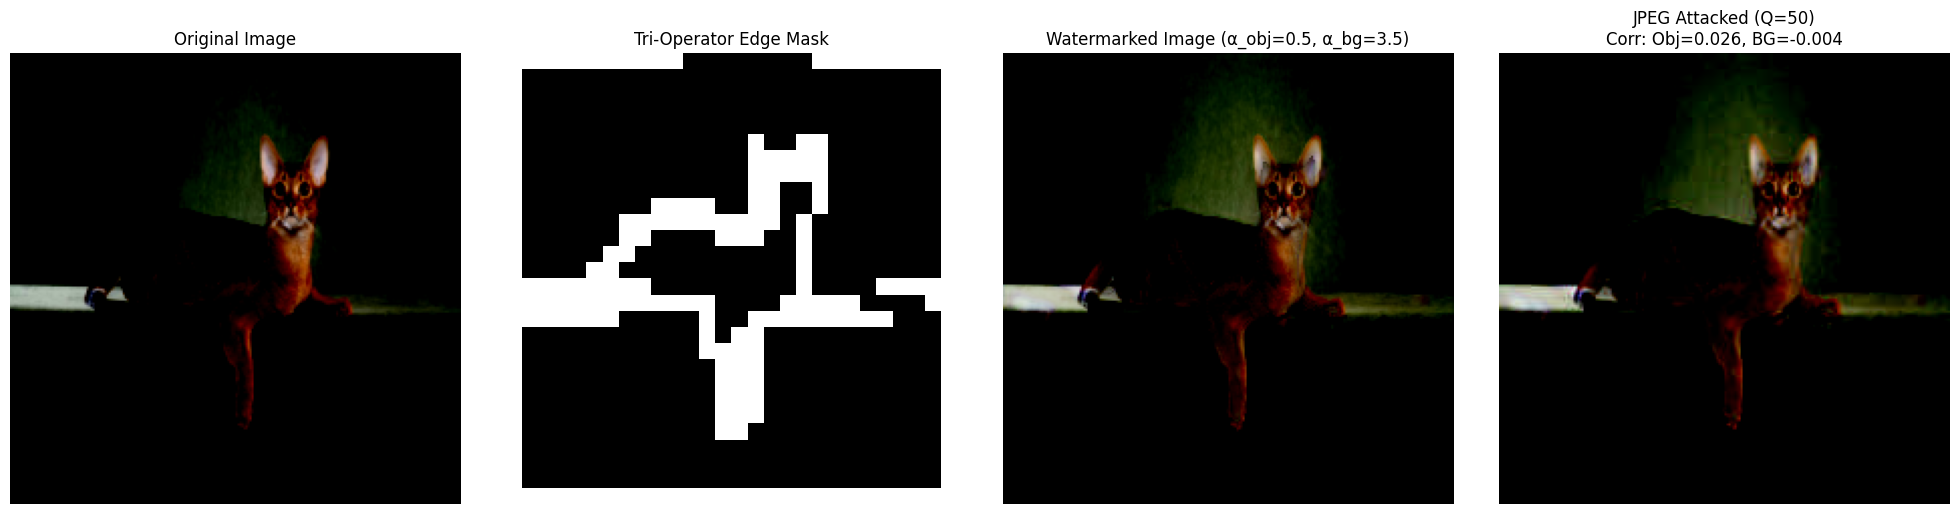

In [20]:
import torch
import json
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import OrderedDict

# Assuming your training script is in the same directory
import train_extractor_scratch as ex

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Load Config Safely
config_path = '/kaggle/working/master_config.json'
with open(config_path, 'r') as f:
    master_json = json.load(f)
config = master_json['stage3_extractor'] 

def clean_ddp_state_dict(state_dict):
    """Fixes the 'module.' prefix issue from DistributedDataParallel saving"""
    clean_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '') if k.startswith('module.') else k
        clean_state_dict[name] = v
    return clean_state_dict

# 2. Load AE (Your original clean autoencoder)
ae = ex.DualAutoencoder().to(device)
ae_raw_state = torch.load(config['ae_weights'], map_location=device)
ae.load_state_dict(clean_ddp_state_dict(ae_raw_state.get('model', ae_raw_state)), strict=True)
ae.eval()

# 3. Load Injector (NO WEIGHTS! Using the new Hybrid Chaotic Math)
injector = ex.SSWatermarkInjector(256, 28, 28, w1_seed="object", w2_seed="background").to(device)
injector.eval()

# 4. Load the Heavy Extractor (The one you just trained to 99% accuracy)
extractor = ex.HeavyWatermarkDecoder(num_res_blocks=6).to(device)
ext_raw_state = torch.load('/kaggle/working/best_model_e2e/best_weights.pth', map_location=device)
if 'model' in ext_raw_state: ext_raw_state = ext_raw_state['model']
extractor.load_state_dict(clean_ddp_state_dict(ext_raw_state), strict=True)
extractor.eval()

# 5. Load Edge Masker & JPEG Attack Layer
edge_masker = ex.TriOperatorEdgeMasker().to(device)
edge_masker.eval()
jpeg_attack = ex.DifferentiableJPEG().to(device)

# 6. Get Image from your dataset (Using the exact paths from your config)
ds = ex.OxfordPetDataset(config['images_dir'], config['mask_dir'], transforms=ex.SegmentTransform(224, p=0.0))
img, mask = ds[0]

# Add batch dimension
img = img.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)

objs = img * mask
bgs  = img * (1.0 - mask)

with torch.inference_mode():
    # A. Generate the Soft Masks and Edge Masks
    soft_masks = TF.gaussian_blur(mask, kernel_size=[15, 15], sigma=[5.0, 5.0])
    edge_mask_obj = edge_masker(objs)
    edge_mask_bg = edge_masker(bgs)

    # B. Generate Watermarked Image (Using Differential Alphas 0.5 and 3.5)
    wm_obj, wm_bg = ae.forward_watermarked(
        objs, bgs, injector, 
        alpha_obj=0.5, alpha_bg=3.5, 
        edge_mask_obj=edge_mask_obj, edge_mask_bg=edge_mask_bg
    )
    
    # Blend using soft masks to prevent seam artifacts
    wm_image = (wm_obj * soft_masks) + (wm_bg * (1.0 - soft_masks))
    
    # C. Apply the Harsh JPEG Attack (Quality 50 is very destructive!)
    attacked_image = jpeg_attack(wm_image, quality=50)
    
    # D. Extract the payload from the attacked image!
    pred_wm, features = extractor(attacked_image, soft_masks)
    
    # E. Calculate spatial correlation against the true chaotic watermarks
    true_w1 = injector.w1.mean(dim=1, keepdim=True).expand(1, -1, -1, -1)
    true_w2 = injector.w2.mean(dim=1, keepdim=True).expand(1, -1, -1, -1)
    target_wm = torch.cat([true_w1, true_w2], dim=1)
    
    corr_obj = F.cosine_similarity(pred_wm[:, 0:1].flatten(1), target_wm[:, 0:1].flatten(1), dim=1).mean()
    corr_bg  = F.cosine_similarity(pred_wm[:, 1:2].flatten(1), target_wm[:, 1:2].flatten(1), dim=1).mean()

# 7. Plotting
def to_numpy(t):
    # FIXED: Images from dataset are [0, 1], so we just multiply by 255
    return (t[0].cpu().permute(1, 2, 0) * 255).clamp(0, 255).byte().numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(to_numpy(img))
axes[0].set_title("Original Image")

# Display the Edge Mask to show where the background watermark is hiding
axes[1].imshow(edge_mask_bg[0, 0].cpu().numpy(), cmap='gray')
axes[1].set_title("Tri-Operator Edge Mask")

axes[2].imshow(to_numpy(wm_image))
axes[2].set_title("Watermarked Image (α_obj=0.5, α_bg=3.5)")

axes[3].imshow(to_numpy(attacked_image))
axes[3].set_title(f"JPEG Attacked (Q=50)\nCorr: Obj={corr_obj.item():.3f}, BG={corr_bg.item():.3f}")

for ax in axes: 
    ax.axis('off')
    
plt.tight_layout()
plt.savefig("attacker_inference_1.png")
plt.show()

In [ ]:
# from collections import OrderedDict

# # 1. Load AE
# ae = ex.DualAutoencoder().to(device)
# ae_state = torch.load(config['ae_weights'], map_location=device)
# ae_state = ae_state.get('model', ae_state)

# # Clean the DDP "module." prefixes
# clean_state_dict = OrderedDict()
# for k, v in ae_state.items():
#     name = k.replace('module.', '') if k.startswith('module.') else k
#     clean_state_dict[name] = v

# # Set strict=True to guarantee it loaded successfully
# ae.load_state_dict(clean_state_dict, strict=True)
# ae.eval()

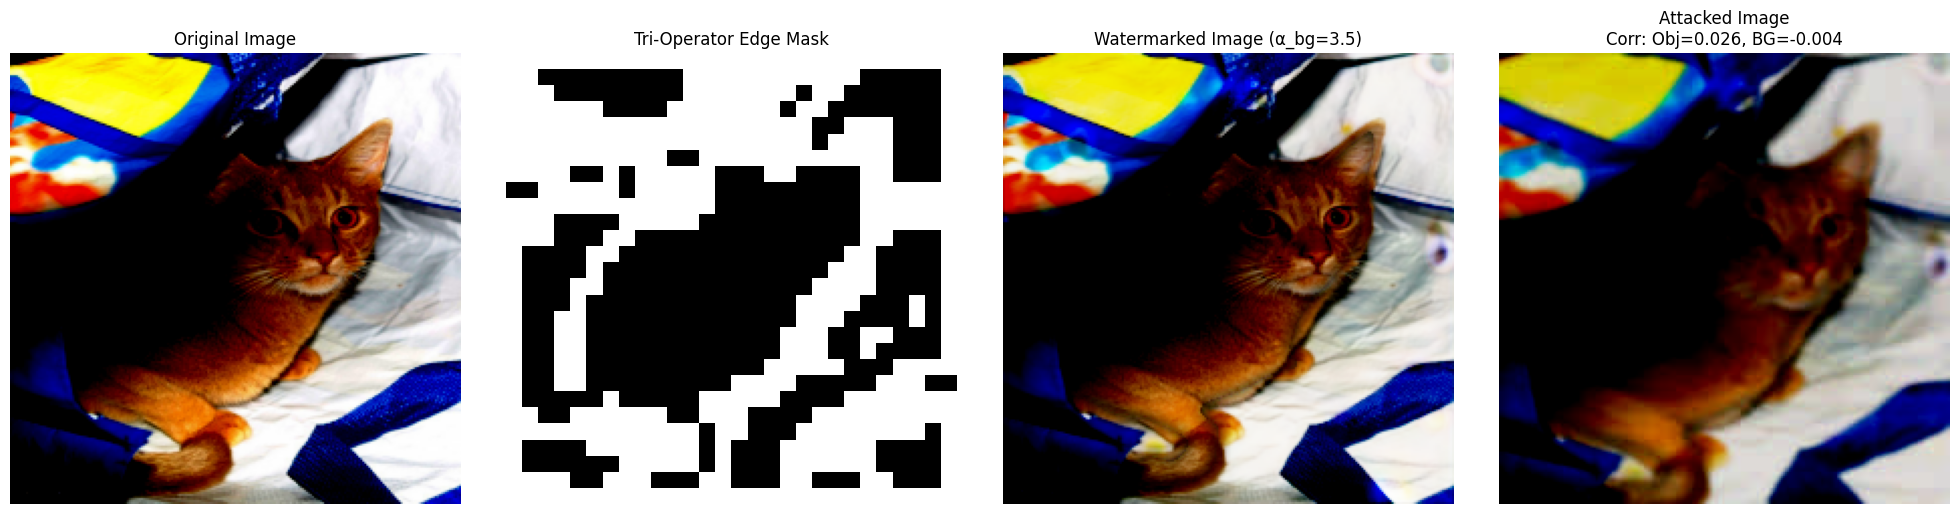

In [21]:
import torch
import json
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import OrderedDict
from torchvision.io import read_image

# 1. FIXED IMPORT: Load the Scratch file where the Heavy Decoder lives
import train_extractor_scratch as ex 

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 2. FIXED CONFIG: Load from master_config.json safely
config_path = '/kaggle/working/master_config.json'
with open(config_path, 'r') as f:
    master_json = json.load(f)
config = master_json['stage3_extractor'] 

def clean_ddp_state_dict(state_dict):
    """Fixes the 'module.' prefix issue from DistributedDataParallel saving"""
    clean_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '') if k.startswith('module.') else k
        clean_state_dict[name] = v
    return clean_state_dict

# 3. Load AE
ae = ex.DualAutoencoder().to(device)
ae_raw_state = torch.load(config['ae_weights'], map_location=device)
ae.load_state_dict(clean_ddp_state_dict(ae_raw_state.get('model', ae_raw_state)), strict=True)
ae.eval()

# 4. FIXED INJECTOR: No weights needed! Generates chaotic math instantly.
injector = ex.SSWatermarkInjector(256, 28, 28, w1_seed="object", w2_seed="background").to(device)
injector.eval()

# 5. Load the Heavy Extractor
extractor = ex.HeavyWatermarkDecoder(num_res_blocks=6).to(device)
ext_raw_state = torch.load('/kaggle/working/best_model_e2e/best_weights.pth', map_location=device)
if 'model' in ext_raw_state: ext_raw_state = ext_raw_state['model']
extractor.load_state_dict(clean_ddp_state_dict(ext_raw_state), strict=True)
extractor.eval()

# 6. Load Edge Masker
edge_masker = ex.TriOperatorEdgeMasker().to(device)
edge_masker.eval()

# 7. Load a Specific Test Image Correctly
img_path = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images/Abyssinian_100.jpg"
mask_path = "/kaggle/input/datasets/mrheavenly/masks-oxford/Abyssinian_100_mask.png"

img_raw = read_image(img_path)
mask_raw = read_image(mask_path)

if img_raw.shape[0] == 4: img_raw = img_raw[:3]
elif img_raw.shape[0] == 1: img_raw = img_raw.repeat(3, 1, 1)

# CRITICAL FIX: Force mask to 1 channel
if mask_raw.shape[0] > 1: mask_raw = mask_raw[0:1, :, :]

img_raw = img_raw.float().div(255.0)
mask_raw = (mask_raw > 127).float()

transform = ex.SegmentTransform(224, p=0.0)
img, mask = transform(img_raw, mask_raw)

# Add batch dimension and send to GPU
img = img.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)

objs = img * mask
bgs  = img * (1.0 - mask)

with torch.inference_mode():
    # A. Generate the Soft Masks and Edge Masks
    soft_masks = TF.gaussian_blur(mask, kernel_size=[15, 15], sigma=[5.0, 5.0])
    edge_mask_obj = edge_masker(objs)
    edge_mask_bg = edge_masker(bgs)

    # B. Generate Watermarked Image
    wm_obj, wm_bg = ae.forward_watermarked(
        objs, bgs, injector, 
        alpha_obj=0.5, alpha_bg=3.5, 
        edge_mask_obj=edge_mask_obj, edge_mask_bg=edge_mask_bg
    )
    
    # Blend using soft masks
    wm_image = (wm_obj * soft_masks) + (wm_bg * (1.0 - soft_masks))
    
    # C. Apply Attack Simulation
    attack_layer = ex.AttackSimulationLayer(p_apply=1.0).to(device)
    attacked_image = attack_layer(wm_image, current_epoch=10, warmup_epochs=0) 
    
    # D. Extract
    try:
        pred_wm, features = extractor(attacked_image, soft_masks)
    except TypeError:
        pred_wm, features = extractor(attacked_image)
    
    # E. Calculate spatial correlation
    true_w1 = injector.w1.mean(dim=1, keepdim=True).expand(1, -1, -1, -1)
    true_w2 = injector.w2.mean(dim=1, keepdim=True).expand(1, -1, -1, -1)
    target_wm = torch.cat([true_w1, true_w2], dim=1)
    
    corr_obj = F.cosine_similarity(pred_wm[:, 0:1].flatten(1), target_wm[:, 0:1].flatten(1), dim=1).mean()
    corr_bg  = F.cosine_similarity(pred_wm[:, 1:2].flatten(1), target_wm[:, 1:2].flatten(1), dim=1).mean()

# 8. FIXED Plotting: Images are [0, 1], just multiply by 255
def to_numpy(t):
    return (t[0].cpu().permute(1, 2, 0) * 255).clamp(0, 255).byte().numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(to_numpy(img))
axes[0].set_title("Original Image")

axes[1].imshow(edge_mask_bg[0, 0].cpu().numpy(), cmap='gray')
axes[1].set_title("Tri-Operator Edge Mask")

axes[2].imshow(to_numpy(wm_image))
axes[2].set_title("Watermarked Image (α_bg=3.5)")

axes[3].imshow(to_numpy(attacked_image))
axes[3].set_title(f"Attacked Image\nCorr: Obj={corr_obj.item():.3f}, BG={corr_bg.item():.3f}")

for ax in axes: 
    ax.axis('off')
    
plt.tight_layout()
plt.savefig("attacker_inference_2.png")
plt.show()

In [ ]:
import shutil
import os
from IPython.display import FileLink, display

def backup_training_run():
    # Paths to your saved folders
    best_dir = '/kaggle/working/best_model_e2e'
    ckpt_dir = '/kaggle/working/checkpoints_e2e'
    
    # 1. Zip the Best Model Directory
    if os.path.exists(best_dir):
        shutil.make_archive('best_model_e2e_backup', 'zip', best_dir)
        print("✅ Zipped Best Model successfully!")
        display(FileLink('best_model_e2e_backup.zip'))
    else:
        print(f"❌ Could not find {best_dir}")

    # 2. Zip the Checkpoints Directory
    if os.path.exists(ckpt_dir):
        shutil.make_archive('checkpoints_e2e_backup', 'zip', ckpt_dir)
        print("✅ Zipped Checkpoints successfully!")
        display(FileLink('checkpoints_e2e_backup.zip'))
    else:
        print(f"❌ Could not find {ckpt_dir}")

# Run the function
backup_training_run()